### Credit Card Fraud Detection

#### Problem statement
To support that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

#### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, average_precision_score, make_scorer, roc_auc_score, confusion_matrix, roc_curve

pd.set_option('display.max_columns', None) 

#### Data Loading

In [3]:
df = pd.read_csv(r"E:\Projects\UWU\Fraud_Analysis\artifacts\data.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,67428.0,0.545137,-1.382002,0.808039,0.325749,-1.216218,0.520418,-0.404707,0.236356,0.843181,-0.479484,1.201117,1.586728,0.345492,-0.346314,-0.760569,-0.196522,0.156950,-0.583192,0.298380,0.540131,0.032340,-0.309100,-0.173193,0.119002,-0.062738,0.921664,-0.074989,0.053908,309.00,0
1,80288.0,1.274782,0.239294,0.126050,0.981467,0.308615,0.288049,0.070181,-0.096043,0.315763,-0.220228,-1.673102,0.968872,1.900641,-0.477572,-0.257424,0.038797,-0.674142,-0.298174,0.562107,0.024280,-0.321162,-0.676714,-0.175115,-0.975418,0.762622,-0.446555,0.045943,0.018644,18.07,0
2,92736.0,-2.442663,-3.250807,-1.081487,0.276296,0.401510,-0.383979,0.261438,0.486404,1.891807,-1.440296,0.253156,-2.153069,1.315606,2.195237,-0.866536,0.882896,-0.578653,2.041002,-0.345580,1.358472,0.851970,0.984857,1.307229,-1.158888,-1.705672,-0.959345,0.149654,-0.049546,506.00,0
3,57773.0,-2.086922,-6.322946,-2.168681,0.926756,-2.522653,-0.144318,2.146822,-0.703704,-0.883657,-0.207525,-1.265627,-0.458195,-0.067967,0.529281,0.291162,-1.382264,0.223794,1.208093,-0.854597,3.192718,0.617022,-1.792547,-1.668460,0.008613,-0.191875,0.930436,-0.418456,0.309412,1832.55,0
4,67862.0,-0.873372,-0.381341,3.111317,-1.452125,-1.447693,0.795084,-1.041973,0.765762,0.220466,-0.134101,0.345279,-0.802325,-2.567425,-0.883266,-2.158383,0.651391,0.907727,-1.018527,0.334955,-0.000809,0.205009,0.861046,-0.342198,0.231057,0.342896,-0.105434,0.345348,0.113345,1.00,0


#### Data Quality Check

In [8]:
print(f'data contains {len(df)} rows and {len(df.columns)} columns')
print(f'Number of missing values {df.isnull().sum()}')

data contains 284807 rows and 31 columns
Number of missing values Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [11]:
# Check duplicates
df.duplicated().sum()

np.int64(1081)

In [12]:
df[df.duplicated(keep=False)]['Class'].value_counts()


Class
0    1822
1      32
Name: count, dtype: int64

In [13]:
#According to this 1854 (1822 + 32) rows involved and 1081 rows removable. So, 773 unique duplicated transactions.

In [14]:
# Remove the duplicated
df_clean = df.drop_duplicates()
df_clean.shape

(283726, 31)

#### Target distribution

In [15]:
class_count = df_clean['Class'].value_counts()
print(class_count)
print(f"Fraud_percentage: {class_count/len(df_clean)*100}")

Class
0    283253
1       473
Name: count, dtype: int64
Fraud_percentage: Class
0    99.83329
1     0.16671
Name: count, dtype: float64


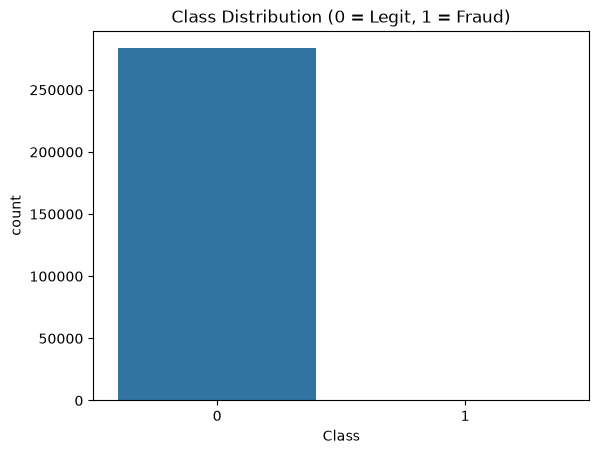

In [16]:
# Class imbalance visualization
sns.countplot(x='Class', data=df_clean)
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.show()

In [17]:
fraud = df_clean[df_clean['Class']==1]
legit = df_clean[df_clean['Class']==0]

In [18]:
fraud.Amount.describe()

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [19]:
legit.Amount.describe()

count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

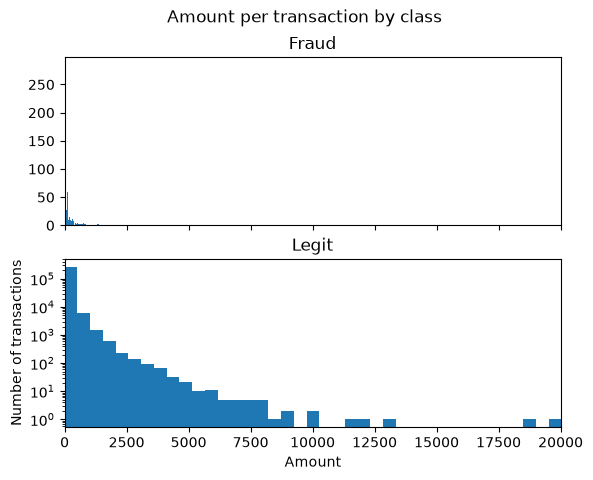

In [20]:
# Amount per tansaction by class
figure, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
figure.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(fraud.Amount, bins=bins)
ax1.set_title('Fraud')
ax2.hist(legit.Amount, bins=bins)
ax2.set_title('Legit')
plt.xlabel('Amount')
plt.ylabel('Number of transactions')
plt.xlim(0,20000)
plt.yscale('log') #visualizing to large range
plt.show()

<Figure size 2000x1500 with 0 Axes>

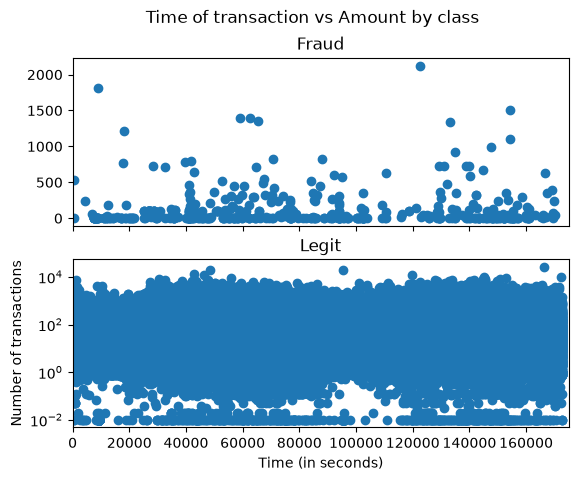

In [21]:
# How often fraudulent transaction occur
plt.figure(figsize=(20,15))
figure, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
figure.suptitle('Time of transaction vs Amount by class')
ax1.scatter(fraud.Time, fraud.Amount)
ax1.set_title('Fraud')
ax2.scatter(legit.Time, legit.Amount)
ax2.set_title('Legit')
plt.xlabel('Time (in seconds)')
plt.ylabel('Number of transactions')
plt.xlim(0,175000)
plt.yscale('log') #visualizing to large range
plt.show()

##### Identify the correlation among features and target

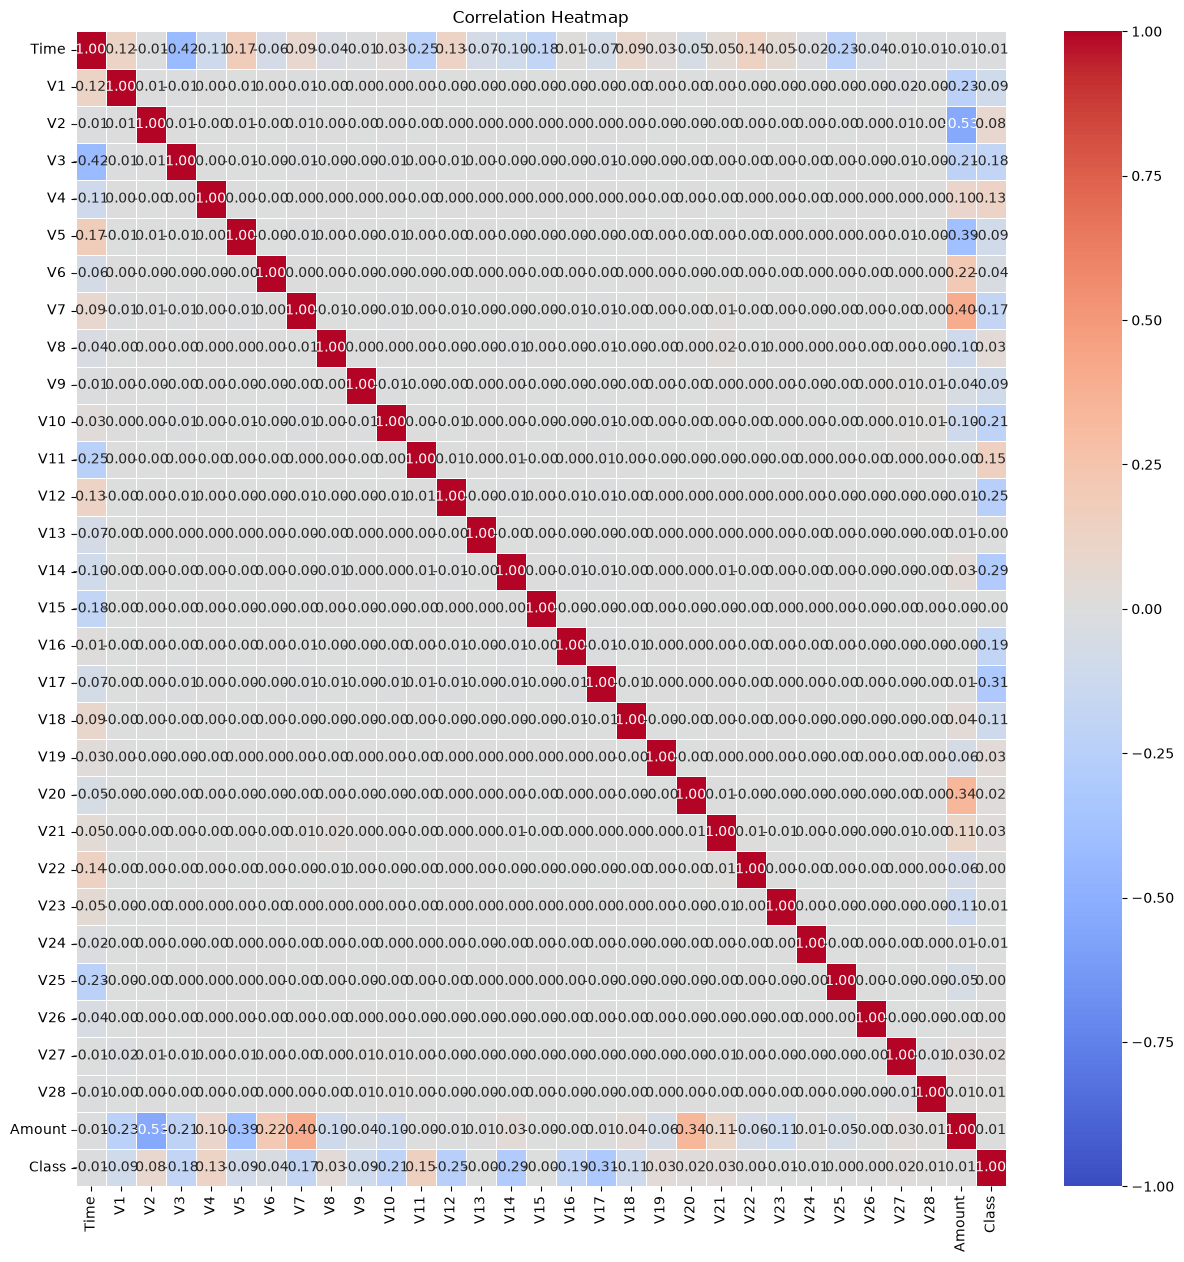

In [22]:
# Correlation heapmap
plt.figure(figsize=(15,15))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

According to the above chart,
- V17, V14, V12, and V10 as they contain the most "signal" regarding fraud as they show strong negative correlations.
- There's no multicollinearity observed between V1 - V28, because their correlations are shown as nearly zero. Assume it's due to PCA transformation. 

### Data Preparation

In [23]:
# Define the independent and dependent features
X = df_clean.drop(['Class', 'Time'],axis=1)
y = df_clean['Class']

In [24]:
# Split train, val, test dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Number of rows in train feature dataset {X_train.shape[0]}, Number of columns in train feature dataset {X_train.shape[1]}')
print(f'Number of rows in validation feature dataset {X_val.shape[0]}, Number of columns in validation feature dataset {X_val.shape[1]}')
print(f'Number of rows in test feature dataset {X_test.shape[0]}, Number of columns in test feature dataset {X_test.shape[1]}')
print("====")

print(f'Number of rows in train target dataset {y_train.shape[0]} and the percentage of Fraud {len(y_train[y_train==1])/len(y_train)*100:.3f}%')
print(f'Number of rows in validation target dataset {y_val.shape[0]} and the percentage of Fraud {len(y_val[y_val==1])/len(y_val)*100:.3f}%')
print(f'Number of rows in test target dataset {y_test.shape[0]} and the percentage of Fraud {len(y_test[y_test==1])/len(y_test)*100:.3f}%')


Number of rows in train feature dataset 170235, Number of columns in train feature dataset 29
Number of rows in validation feature dataset 56745, Number of columns in validation feature dataset 29
Number of rows in test feature dataset 56746, Number of columns in test feature dataset 29
====
Number of rows in train target dataset 170235 and the percentage of Fraud 0.167%
Number of rows in validation target dataset 56745 and the percentage of Fraud 0.166%
Number of rows in test target dataset 56746 and the percentage of Fraud 0.167%


### Selection of models
- Logistic Regression (Baseline Model)
- Random Forest (Core Model)
- XGBoost (Core Model)
- LightGBM (Core Model)

1. Baseline model

In [25]:
# Using the standara scaler only for basemodel (logistic regression), Rest tree base models are not required standard scaler
scaler = StandardScaler()

# Get the copy of orginal data split as we need  
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Create the scaled version for Logistic Regression
X_train_scaled['Amount_scaled'] = scaler.fit_transform(X_train[['Amount']])
X_val_scaled['Amount_scaled'] = scaler.transform(X_val[['Amount']])
X_test_scaled['Amount_scaled'] = scaler.transform(X_test[['Amount']])

X_train_scaled.drop('Amount', axis=1, inplace=True)
X_val_scaled.drop('Amount', axis=1, inplace=True)
X_test_scaled.drop('Amount', axis=1, inplace=True)

# Logistic Regression
lr_model = LogisticRegression(
    solver='liblinear', 
    class_weight='balanced',
    random_state=42
)

# Train the model & predict probabilities
lr_model.fit(X_train_scaled, y_train)
y_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
y_val_pred = lr_model.predict(X_val_scaled)

In [26]:
# Baseline model evaluation
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

f1_score_lr = f1_score(y_val, y_val_pred)
pr_auc_lr = average_precision_score(y_val, y_val_proba)
print("PR-AUC:", pr_auc_lr)
print("f1_score",f1_score_lr)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.86      0.11        94

    accuracy                           0.98     56745
   macro avg       0.53      0.92      0.55     56745
weighted avg       1.00      0.98      0.99     56745

[[55349  1302]
 [   13    81]]
PR-AUC: 0.6927143430665853
f1_score 0.10968178740690589


2. Random Forest - Core model

In [27]:
# Random Forest
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Train the model & predict probabilities
rf_model.fit(X_train, y_train)
y_val_proba = rf_model.predict_proba(X_val)[:, 1]
y_val_pred = rf_model.predict(X_val)

In [28]:
# random forest model evaluation
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

f1_score_rf = f1_score(y_val, y_val_pred)
pr_auc_rf = average_precision_score(y_val, y_val_proba)
print("PR-AUC:", pr_auc_rf)
print("f1_score",f1_score_rf)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        94

    accuracy                           1.00     56745
   macro avg       0.96      0.88      0.92     56745
weighted avg       1.00      1.00      1.00     56745

[[56645     6]
 [   23    71]]
PR-AUC: 0.796506791344493
f1_score 0.8304093567251462


3. XGBoost - CoreModel

In [29]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42
)

# Train the model & predict probabilities
xgb_model.fit(X_train, y_train)
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred = xgb_model.predict(X_val)

In [32]:
# xgboost model evaluation
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

f1_score_xgb = f1_score(y_val, y_val_pred)
pr_auc_xgb = average_precision_score(y_val, y_val_proba)
print("PR-AUC:", pr_auc_xgb)
print("f1_score",f1_score_xgb)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.73      0.81        94

    accuracy                           1.00     56745
   macro avg       0.95      0.87      0.90     56745
weighted avg       1.00      1.00      1.00     56745

[[56643     8]
 [   25    69]]
PR-AUC: 0.7853384370531833
f1_score 0.8070175438596491


4. LightGBM - CoreModel

In [33]:
# LighGBM
lgbm_model = lgb.LGBMClassifier(
    class_weight = "balanced",
    random_state=42
)

# Train the model & predict probabilities
lgbm_model.fit(X_train, y_train)
y_val_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = lgbm_model.predict(X_val)

[LightGBM] [Info] Number of positive: 284, number of negative: 169951
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008987 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 170235, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [34]:
# lightgbm model evaluation
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

f1_score_lgb = f1_score(y_val, y_val_pred)
pr_auc_lgb = average_precision_score(y_val, y_val_proba)
print("PR-AUC:", pr_auc_lgb)
print("f1_score",f1_score_lgb)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.86      0.74      0.80        94

    accuracy                           1.00     56745
   macro avg       0.93      0.87      0.90     56745
weighted avg       1.00      1.00      1.00     56745

[[56640    11]
 [   24    70]]
PR-AUC: 0.7808072259735277
f1_score 0.8


#### Hyperparameter Optimization

Looking at the performance baseline, I’m moving forward with tuning only the tree-based models as the tree based models are outperformed logistic regression. Logistic Regression generates an operationally unacceptable number of false positives. Also linear decision boundaries cannot capture the interaction heavy, non linear nature of fraud patterns. 
So, tuning hyper parameters for logistic regression not going to benifit compared to tree based models. 

In [35]:
models = {
    "Random Forest": RandomForestClassifier(),
    "XGBoost": xgb.XGBClassifier(),
    "LightGBM": lgb.LGBMClassifier()
}

In [36]:
params = {
    "Random Forest": {
        "n_estimators": [200, 400],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 2, 5],
        "min_samples_split": [2, 5],
        "class_weight": ["balanced"],
        "max_features": ["sqrt"],
        "n_jobs": [-1]
    },
    "XGBoost": {
        "n_estimators": [300, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "scale_pos_weight": [(y_train == 0).sum() / (y_train == 1).sum()],
        "objective": ["binary:logistic"],
        "eval_metric": ["aucpr"],
        "n_jobs": [-1]
    },
    "LightGBM": {
        "n_estimators": [300, 500],
        "learning_rate": [0.05, 0.1],
        "num_leaves": [31, 63, 127],
        "max_depth": [-1, 10, 20],
        "min_child_samples": [20, 50],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "class_weight": ["balanced"],
        "objective": ["binary"],
        "metric": ["aucpr"],
        "n_jobs": [-1],
        "verbose": [-1]
    }
    }

In [37]:
def tuning_model(models, X_train, y_train, X_val, y_val):
    
    param_report = []
    fraud_recall_scorer = make_scorer(recall_score, pos_label=1)

    for model_name, model in models.items():

        print(f"\n Tuning model: {model_name}")
        param_grid = params[model_name]

        rs = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            n_iter=10,
            scoring=fraud_recall_scorer,
            cv=3,
            n_jobs=-1,
            random_state=42,
            verbose=1
        )

        rs.fit(X_train,y_train)

        best_model = rs.best_estimator_

        #Evaluate on validation set
        y_val_prob = best_model.predict_proba(X_val)[:1]
        y_val_pred = best_model.predict(X_val)

        report = {
            "model": model_name,
            "best_param": rs.best_params_,
            "recall": recall_score(y_val,y_val_pred),
            "pr_auc": average_precision_score(y_val,y_val_pred),
            "f1_score": f1_score(y_val,y_val_pred)
        }

        param_report.append(report)

    return pd.DataFrame(param_report)

In [38]:
param_df = tuning_model(models, X_train, y_train, X_val, y_val)
param_df


 Tuning model: Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Tuning model: XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Tuning model: LightGBM
Fitting 3 folds for each of 10 candidates, totalling 30 fits


,model,best_param,recall,pr_auc,f1_score
0,Random Forest,"{'n_jobs': -1, 'n_estimators': 400, 'min_sampl...",0.797872,0.604784,0.777202
1,XGBoost,"{'subsample': 1.0, 'scale_pos_weight': 598.419...",0.808511,0.257417,0.456456
2,LightGBM,"{'verbose': -1, 'subsample': 0.8, 'objective':...",0.734043,0.694262,0.826347


Based on the tuning results, the XGBoost model's F1-score didn't show significant improvement after optimization. However, because I observed a lift in Recall, the model is now better at capturing fraudulent transactions, which aligns with our primary objective. Therefore, I have decided to proceed with these tuned hyperparameters for the final training phase.

#### Training the dataset for each model with best parameter
#### Do evaluation on Test dataset

In [39]:
def evaluate_tuned_model(models, param_df, X_train, y_train, X_test, y_test):

        results = []

        for model_name, model_obj in models.items():
                best_param = param_df[param_df['model']==model_name]['best_param'].values[0]
                model = model_obj.set_params(**best_param)

                #Train the model using best parameter derived
                model.fit(X_train, y_train)

                #Predictions
                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:,1]

                #Evaluations
                metrics = {
                        "Model": model_name,
                        "Precision": precision_score(y_test, y_pred),
                        "Recall": recall_score(y_test, y_pred),
                        "F1_Score": f1_score(y_test, y_pred),
                        "ROC_AUC": roc_auc_score(y_test, y_proba),
                        "PR_AUC": average_precision_score(y_test, y_proba)
                }

                results.append(metrics)

                print(f"\n==={model_name}===\n")
                print("Classification Report:\n", classification_report(y_test, y_pred))
                print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

                # Get the ROC Curve
                fpr, tpr, thresholds = roc_curve(y_test, y_proba)
                # Plot ROC Curve
                plt.figure(figsize=(10,5))
                plt.plot(fpr, tpr, label = f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")
                plt.plot([0,1],[0,1], linestyle='--', label= f'{model_name}')

                plt.xlabel('False Positive Rate')
                plt.ylabel('True Positive Rate')
                plt.title(f'ROC Curve - {model_name}')
                plt.legend()
                plt.grid(True)
                plt.show()

        return pd.DataFrame(results)


===Random Forest===

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.76      0.82      0.79        95

    accuracy                           1.00     56746
   macro avg       0.88      0.91      0.89     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
 [[56626    25]
 [   17    78]]


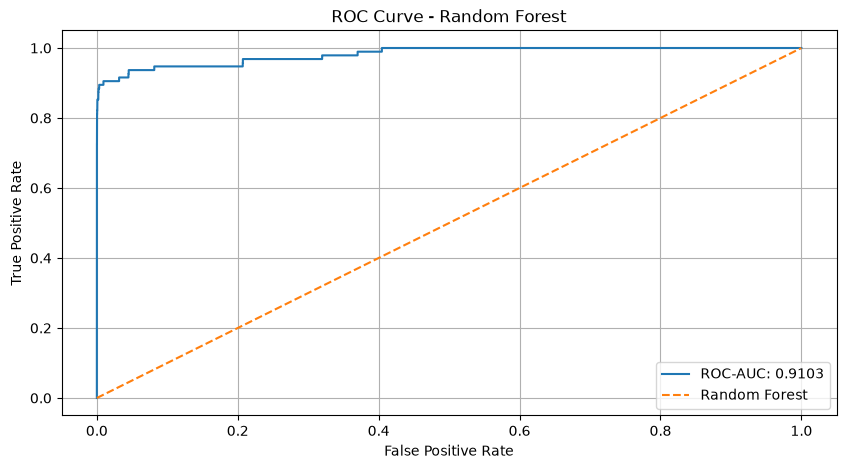


===XGBoost===

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.35      0.87      0.50        95

    accuracy                           1.00     56746
   macro avg       0.67      0.94      0.75     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
 [[56497   154]
 [   12    83]]


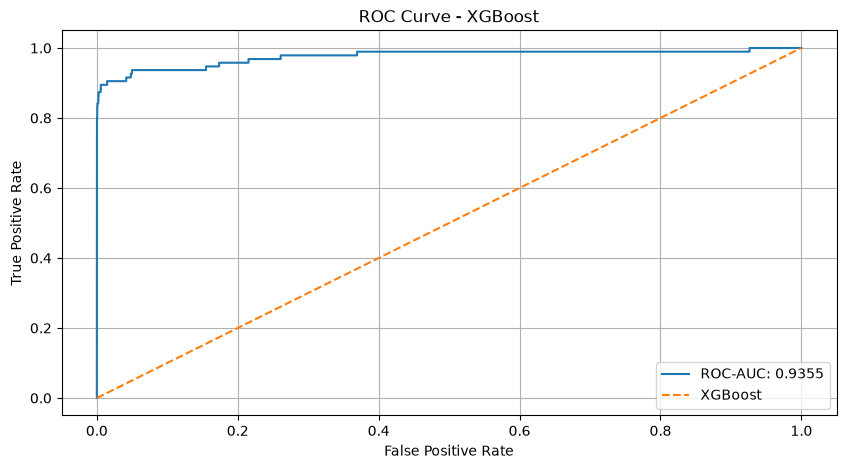


===LightGBM===

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.81      0.88        95

    accuracy                           1.00     56746
   macro avg       0.98      0.91      0.94     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
 [[56647     4]
 [   18    77]]


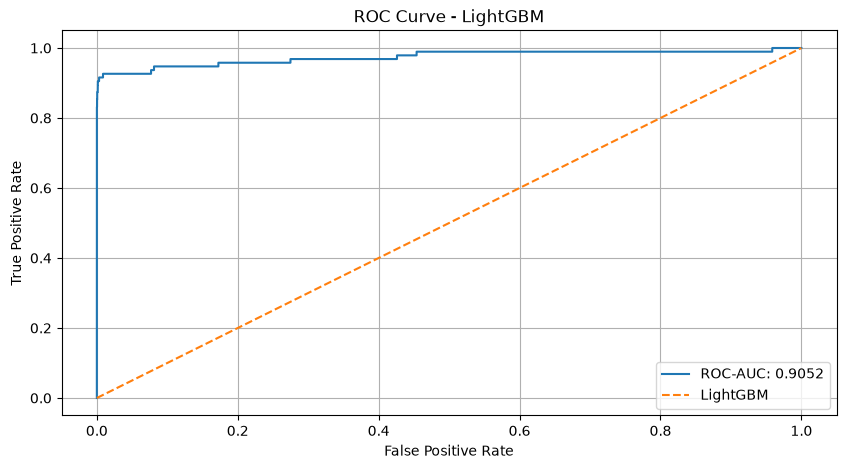

,Model,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,Random Forest,0.757282,0.821053,0.787879,0.981713,0.826307
1,XGBoost,0.350211,0.873684,0.500000,0.975993,0.776140
2,LightGBM,0.950617,0.810526,0.875000,0.974072,0.868214


In [40]:
evaluation = evaluate_tuned_model(models, param_df, X_train, y_train, X_test, y_test)
evaluation

As per the project objective of maximizing fraud detection while minimizing false alarms, I have prioritized Precision and Recall as our primary metrics. While LightGBM provides the most balance offering the highest F1-Score and a superior PR-AUC while XGBoost remains an alternative for its peak Recall. Ultimately, I recommend proceeding with LightGBM as it delivers the most stable performance across all key indicators.